## This reproduces Figure 1 of Dai & Li 2006

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os
from cycler import cycler
home = os.path.expanduser("~")
stylefile = f"{home}/.config/matplotlib/stylelib/paper.mplstyle"
plt.style.use(stylefile)

base_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
linestyles = ["-", "--", "-.", ":"]
plt.rcParams["axes.prop_cycle"] = cycler(color=base_colors) + cycler(
    linestyle=[linestyles[i % len(linestyles)] for i in range(len(base_colors))]
)

In [24]:
def func_n(n, K):
    return n**-3.25 - n**-2.25 + K

## Value of the function as a function of n and K

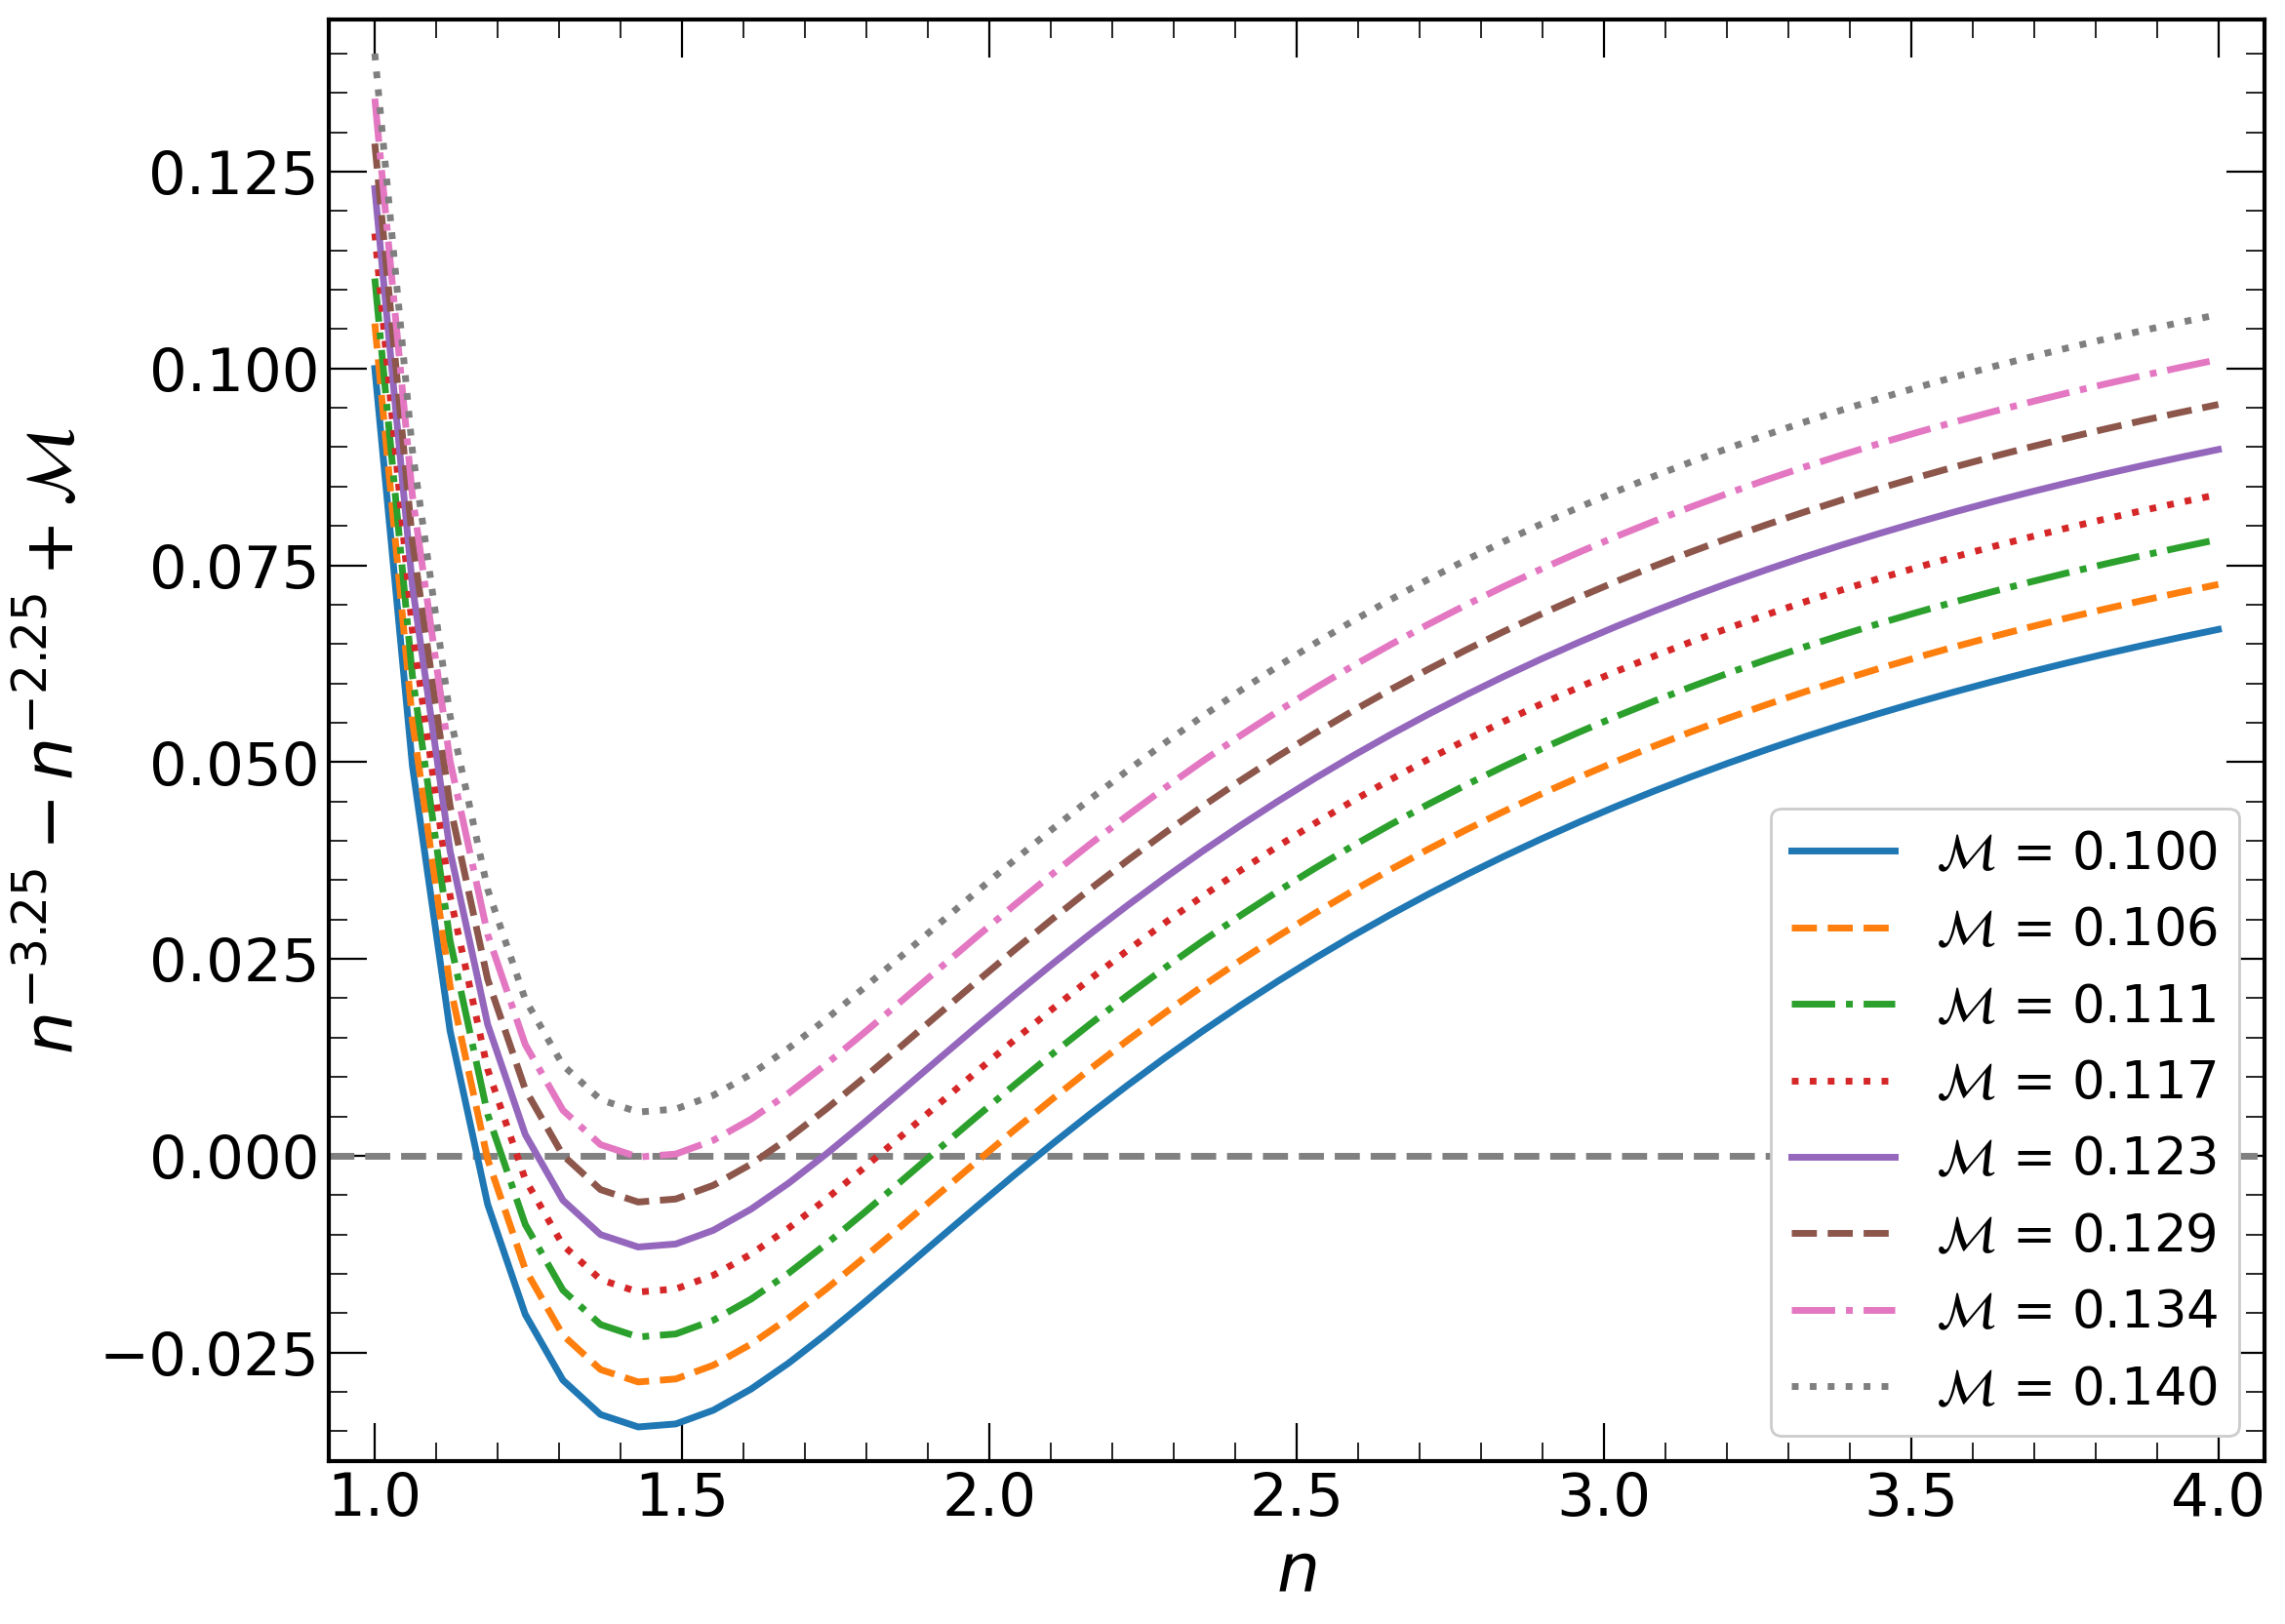

In [35]:
n = np.linspace(1, 4)
M = np.linspace(0.1, 0.14, 8)
fig, ax = plt.subplots()
plt.axhline(0, ls="--", color="gray")
for m in M:
    values = func_n(n, m)
    plt.plot(n, values, label=r"$\mathcal{M}$ = %.3f" %m)

handles, labels = ax.get_legend_handles_labels()

# Sort by M_values directly (assumes same order as plot calls)
sorted_pairs = sorted(zip(M, handles, labels), key=lambda x: x[0])
_, handles, labels = zip(*sorted_pairs)

ax.legend(handles, labels, framealpha=1)
plt.xlabel("$n$")
plt.ylabel(r"$n^{-3.25} - n^{-2.25} + \mathcal{M}$")
plt.savefig("payne_continuity")